In [1]:
#!/usr/bin/env python
from __future__ import annotations
import os
import sys
import math
import argparse
import importlib
import io
import contextlib
from tqdm import tqdm
import glob
import json

from ctypes import c_double
import numpy as np
import uproot
import awkward as ak
import ROOT

# project roots
notebook_dir = '/users/ang.li/public/GluonPDF/HEPHY-uncertainty/user/ang'
os.chdir(notebook_dir)
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '../../')))

import common.user as user
import common.syncer as syncer
import common.yaml_loader as yaml_loader
from pdf.PDFParametrization import PDFParametrization

from fit.Likelihood import load_likelihood
from fit.Likelihood import build_hypothesis_from_likelihood
from fit.Modeling import Rotated

In [2]:
def makehists(x,bins,weights,name):
    h, _ = np.histogram(x, bins=bins, weights=weights)
    hroot = ROOT.TH1D("h"+name, "h", len(bins)-1, np.array(bins,dtype=float))
    for b in range(1,len(bins)):
        hroot.SetBinContent(b, float(h[b-1]))
    return hroot

def rebinhists(h,bins,sfs):
    assert(len(bins)-1 == len(sfs))
    h = h.Rebin(len(bins)-1, h.GetName()+"_rebin", np.array(bins,dtype=float))
    for b in range(1,len(bins)):
        h.SetBinContent(b, h.GetBinContent(b)*sfs[b-1])
    return h

In [3]:
input_paths=[os.path.join(
        "/scratch-cbe/users/robert.schoefbeck/SBIPDF/output/Hgg-gen-ntuples/",
        "RunIISummer20UL16NanoAODAPVv9__GluGluHToGG_M125_TuneCP5_13TeV-amcatnloFXFX-pythia8__106X_mcRun2_asymptotic_preVFP_v11-v2/",
    )]

for p in input_paths:
    files = glob.glob(f"{p}/*.root")

print(f"Found {len(files)} files")


Found 18 files


In [4]:
branches = [
    "Generator_scalePDF",
    "Generator_x1",
    "Generator_x2",
    "Generator_id1",
    "Generator_id2",
    "H_pt",
    "H_y",
    "Generator_weight",
    "LHEPdfWeight"
]

arrays = uproot.concatenate(
    {file: "Events" for file in files},
    expressions=branches,
    library="ak"   # awkward arrays
)

# Access data
x1 = arrays["Generator_x1"]
x2 = arrays["Generator_x2"]
id1 = arrays["Generator_id1"]
id2 = arrays["Generator_id2"]
Q = arrays["Generator_scalePDF"]
h_pt = arrays["H_pt"]
h_y = arrays["H_y"]
gen_weight = arrays["Generator_weight"]
pdf_weights = arrays["LHEPdfWeight"]


In [5]:
h_y_abs = np.abs(h_y)
#lumi = 19.5  # in fb^-1
lumi = 1
xsec = 36200  # in fb
# Calculate event weights
xsec_weights = (lumi * xsec) / np.sum(gen_weight)

y_bins = [0,1,1.5,2.0,2.5]
n_slices = len(y_bins) - 1
xmin = 0
xmax = 200
nxbins = 10
bins = np.linspace(xmin,xmax,nxbins+1)
bin_width = (xmax - xmin) / nxbins

xsec_weights = xsec_weights/bin_width

In [6]:
newbins_last = np.array([0,40,80,120,200],dtype=float)
sfs_last = np.array([0.5,0.5,0.5,0.25],dtype=float)
newbins_mid = np.array([0,20,40,60,100,140,200],dtype=float)
sfs_mid = np.array([1,1,1,0.5,0.5,1.0/3],dtype=float)

In [7]:
hs = {}
n_slices = len(y_bins) - 1
for i in range(n_slices):
    #sel = (h_y_abs >= y_bins[i]) & (h_y_abs < y_bins[i+1]) & (id1==21) & (id2==21)
    sel = (h_y_abs >= y_bins[i]) & (h_y_abs < y_bins[i+1])
    if i==n_slices-1:
        hs[f"slice_{i}"] = rebinhists(h=makehists(h_pt[sel], bins=bins, weights=xsec_weights*gen_weight[sel],name=f"{i}"), bins=newbins_last, sfs=sfs_last)
    elif i!=0:
        hs[f"slice_{i}"] = rebinhists(h=makehists(h_pt[sel], bins=bins, weights=xsec_weights*gen_weight[sel],name=f"{i}"), bins=newbins_mid, sfs=sfs_mid)
    else:
        hs[f"slice_{i}"] = makehists(h_pt[sel], bins=bins, weights=xsec_weights*gen_weight[sel],name=f"{i}")

hs_vars = {}
for i in range(101):
    hs_vars[i] = {}
    for j in range(n_slices):
        #sel = (h_y_abs >= y_bins[j]) & (h_y_abs < y_bins[j+1]) & (id1==21) & (id2==21)
        sel = (h_y_abs >= y_bins[j]) & (h_y_abs < y_bins[j+1])
        if j==n_slices-1:
            hs_vars[i][f"slice_{j}"] = rebinhists(h=makehists(h_pt[sel], bins=bins, weights=xsec_weights*gen_weight[sel]*pdf_weights[:,i][sel],name=f"{i}_{j}"), bins=newbins_last, sfs=sfs_last)
        elif j!=0:
            hs_vars[i][f"slice_{j}"] = rebinhists(h=makehists(h_pt[sel], bins=bins, weights=xsec_weights*gen_weight[sel]*pdf_weights[:,i][sel],name=f"{i}_{j}"), bins=newbins_mid, sfs=sfs_mid)
        else:
            hs_vars[i][f"slice_{j}"] = makehists(h_pt[sel], bins=bins, weights=xsec_weights*gen_weight[sel]*pdf_weights[:,i][sel],name=f"{i}_{j}")

In [8]:
f_all = []
for i in range(100):
    f_all.append(ROOT.TFile.Open(f"/scratch-cbe/users/ang.li/PDFToys_binned/hists_toys_{i}.root"))
hs_binned = {}
for i in range(n_slices):
    if i==n_slices-1:
        hs_binned[f"slice_{i}"] = rebinhists(h=f_all[0].Get(f"hnom_y{i}"), bins=newbins_last, sfs=sfs_last)
    elif i!=0:
        hs_binned[f"slice_{i}"] = rebinhists(h=f_all[0].Get(f"hnom_y{i}"), bins=newbins_mid, sfs=sfs_mid)
    else:
        hs_binned[f"slice_{i}"] = f_all[0].Get(f"hnom_y{i}")

hs_binned_vars = {}
for i in range(100):
    for k in range(100):
        hs_binned_vars[i*100+k] = {}
        for j in range(n_slices):
            if j==n_slices-1:
                hs_binned_vars[i*100+k][f"slice_{j}"] = rebinhists(h=f_all[i].Get(f"htoy_y{j}_var{k}").Clone(f"htoy_y{j}_var{i*100+k}"), bins=newbins_last, sfs=sfs_last)
            elif j!=0:
                hs_binned_vars[i*100+k][f"slice_{j}"] = rebinhists(h=f_all[i].Get(f"htoy_y{j}_var{k}").Clone(f"htoy_y{j}_var{i*100+k}"), bins=newbins_mid, sfs=sfs_mid)
            else:
                hs_binned_vars[i*100+k][f"slice_{j}"] = f_all[i].Get(f"htoy_y{j}_var{k}").Clone(f"htoy_y{j}_var{i*100+k}")

In [9]:
fu_all = []
for i in range(100):
    fu_all.append(ROOT.TFile.Open(f"/scratch-cbe/users/ang.li/PDFToys_unbinned/hists_toys_{i}.root"))
hs_unbinned = {}
for i in range(n_slices):
    if i==n_slices-1:
        hs_unbinned[f"slice_{i}"] = rebinhists(h=fu_all[0].Get(f"hnom_y{i}"), bins=newbins_last, sfs=sfs_last)
    elif i!=0:
        hs_unbinned[f"slice_{i}"] = rebinhists(h=fu_all[0].Get(f"hnom_y{i}"), bins=newbins_mid, sfs=sfs_mid)
    else:
        hs_unbinned[f"slice_{i}"] = fu_all[0].Get(f"hnom_y{i}")

hs_unbinned_vars = {}
for i in range(100):
    for k in range(100):
        hs_unbinned_vars[i*100+k] = {}
        for j in range(n_slices):
            if j==n_slices-1:
                hs_unbinned_vars[i*100+k][f"slice_{j}"] = rebinhists(h=fu_all[i].Get(f"htoy_y{j}_var{k}").Clone(f"htoy_y{j}_var{i*100+k}"), bins=newbins_last, sfs=sfs_last)
            elif j!=0:
                hs_unbinned_vars[i*100+k][f"slice_{j}"] = rebinhists(h=fu_all[i].Get(f"htoy_y{j}_var{k}").Clone(f"htoy_y{j}_var{i*100+k}"), bins=newbins_mid, sfs=sfs_mid)
            else:
                hs_unbinned_vars[i*100+k][f"slice_{j}"] = fu_all[i].Get(f"htoy_y{j}_var{k}").Clone(f"htoy_y{j}_var{i*100+k}")

In [10]:
def calculate_envelop(hs,hs_vars,method):
    gs = {}
    for i in range(n_slices):
        g = ROOT.TGraphAsymmErrors()
        h_nom = hs[f"slice_{i}"]
        for ibin in range(1,h_nom.GetNbinsX()+1):
            variations = []
            for j in range(len(hs_vars.keys())):
                variations.append(hs_vars[j][f"slice_{i}"].GetBinContent(ibin))
            #variations = np.sort(variations)
            variations = np.array(variations)

            diffs = variations-h_nom.GetBinContent(ibin)
            if method=='hessian':
                err = np.sum(diffs**2)**0.5
                errup = err
                errdn = err
                #print(f"Bin {ibin}: nominal={h_nom.GetBinContent(ibin)}, err={err}")
            elif method=='stddev':
                err = (np.sum(diffs**2)/len(variations))**0.5
                errup = err
                errdn = err
            elif method=='envelope':
                variations = np.sort(variations)
                q16 = np.quantile(variations, 0.16, axis=0)
                q84 = np.quantile(variations, 0.84, axis=0)
                errdn = h_nom.GetBinContent(ibin)-q16
                errup = q84-h_nom.GetBinContent(ibin)
                #print(f"Bin {ibin}: nominal={h_nom.GetBinContent(ibin)}, 16th={q16}, 84th={q84}, errdn={errdn}, errup={errup}")

            #diffs = variations-h_nom.GetBinContent(ibin)
            #err = (np.sum(diffs**2)/len(variations))**0.5
            #print(f"Bin {ibin}: nominal={h_nom.GetBinContent(ibin)}, var[0]={variations[0]}, err={err}")
            #print(f"Bin {ibin}: nominal={h_nom.GetBinContent(ibin)}, var[0]={variations[0]}, minvar={min(variations)}, maxvar={max(variations)}, errdn={variations[0]-min(variations)}, errup={max(variations)-variations[0]}")
            
            #p16 = variations[int(0.16*len(variations))]
            #p84 = variations[int(0.84*len(variations))]
            #p16 = min(variations)
            #p84 = max(variations)
            #print(f"Bin {ibin}: nominal={h_nom.GetBinContent(ibin)}, 16th={p16}, 84th={p84}")
            g.SetPoint(ibin-1, h_nom.GetBinCenter(ibin), h_nom.GetBinContent(ibin))
            #g.SetPointError(ibin-1, 0, 0, h_nom.GetBinContent(ibin)-p16, p84-h_nom.GetBinContent(ibin))
            g.SetPointError(ibin-1, h_nom.GetBinWidth(ibin)/2, h_nom.GetBinWidth(ibin)/2, errup, errdn)
        g.SetName(f"envelope_slice_{i}")
        gs[f"slice_{i}"] = g
    return gs


In [11]:
gs_unbinned = calculate_envelop(hs_unbinned,hs_unbinned_vars,method='envelope')
gs_binned = calculate_envelop(hs_binned,hs_binned_vars,method='envelope')
gs = calculate_envelop(hs,hs_vars,method='hessian')

In [12]:
def modifylabels(axis):
    labels = {
        1: "0",
        2: "100",
        3: "0",
        4: "100",
        5: "0",
        6: "100",
        7: "0",
        8: "100",
        9: "200",
    }
    for i in labels:
        axis.ChangeLabel(i, -1,0.09,-1,-1,-1, labels[i])

In [28]:
def organize_g(gs,name):
    g = ROOT.TGraphAsymmErrors()
    g.SetName(f"g_all_{name}")
    ibin=0
    # vertical separator lines
    line_pos = []
    gmax = 0
    xmax = 0
    x_prev = 0
    for i in range(n_slices):
        nbins = gs[f"slice_{i}"].GetN()
        x = c_double(0)
        y = c_double(0)
        gs[f"slice_{i}"].GetPoint(0, x, y)
        x_min = x.value-gs[f"slice_{i}"].GetErrorXlow(0)
        gs[f"slice_{i}"].GetPoint(nbins-1, x, y)
        x_max = x.value+gs[f"slice_{i}"].GetErrorXhigh(nbins-1)
        
        g_width = x_max - x_min
        print(x_min,x_max,g_width)
        for ib in range(nbins):
            x = c_double(0)
            y = c_double(0)
            gs[f"slice_{i}"].GetPoint(ib, x, y)
            exl = gs[f"slice_{i}"].GetErrorXlow(ib)
            exh = gs[f"slice_{i}"].GetErrorXhigh(ib)
            eyl = gs[f"slice_{i}"].GetErrorYlow(ib)
            eyh = gs[f"slice_{i}"].GetErrorYhigh(ib)

            g.SetPoint(ibin, x_prev+x.value, y.value)
            g.SetPointError(ibin, exl, exh, eyl, eyh)
            gmax = max(gmax, y.value+eyh)
            #print(f"Slice {i}, bin {ib}: x={x.value}, y={y.value}, exl={exl}, exh={exh}, eyl={eyl}, eyh={eyh}")
            ibin += 1
        x_prev += g_width
        line_pos.append(x_prev)

    gerr = g.Clone(f"gerr_{name}")
    gerrup = ROOT.TGraphAsymmErrors()
    gerrdn = ROOT.TGraphAsymmErrors()

    for ib in range(g.GetN()):
            x = c_double(0)
            y = c_double(0)
            g.GetPoint(ib, x, y)
            exl = g.GetErrorXlow(ib)
            exh = g.GetErrorXhigh(ib)
            eyl = g.GetErrorYlow(ib)/y.value
            eyh = g.GetErrorYhigh(ib)/y.value

            gerr.SetPoint(ib, x.value, 1)
            gerr.SetPointError(ib, exl, exh, eyl, eyh)

            gerrup.SetPoint(3*ib, x.value-exl, 1+eyh)
            gerrup.SetPointError(3*ib, 0, 0, 0, 0)
            gerrdn.SetPoint(3*ib, x.value-exl, 1-eyl)
            gerrdn.SetPointError(3*ib, 0, 0, 0, 0)
            
            gerrup.SetPoint(3*ib+1, x.value, 1+eyh)
            gerrup.SetPointError(3*ib+1, exl, exh, 0, 0)
            gerrdn.SetPoint(3*ib+1, x.value, 1-eyl)
            gerrdn.SetPointError(3*ib+1, exl, exh, 0, 0)

            gerrup.SetPoint(3*ib+2, x.value+exh, 1+eyh)
            gerrup.SetPointError(3*ib+2, 0, 0, 0, 0)
            gerrdn.SetPoint(3*ib+2, x.value+exh, 1-eyl)
            gerrdn.SetPointError(3*ib+2, 0, 0, 0, 0)

    return g, gerr, gerrup, gerrdn, line_pos, gmax, x_prev

In [14]:
def setgtotarget(g,gtarget):
    assert(g.GetN() == gtarget.GetN())
    for ib in range(g.GetN()):
            x = c_double(0)
            y = c_double(0)
            gtarget.GetPoint(ib, x, y)
            exl = g.GetErrorXlow(ib)
            exh = g.GetErrorXhigh(ib)
            eyl = g.GetErrorYlow(ib)
            eyh = g.GetErrorYhigh(ib)

            g.SetPoint(ib, x.value, y.value)
            g.SetPointError(ib, exl, exh, eyl, eyh)

In [29]:
g, gerr, gerrup, gerrdn, line_pos, gmax, xmax = organize_g(gs, "")
gu, guerr, guerrup, guerrdn, line_posu, gumax,xmaxu = organize_g(gs_unbinned, "unbinned")
gb, gberr, gberrup, gberrdn, line_posb, gbmax,xmaxb = organize_g(gs_binned, "binned")
setgtotarget(gu,g)
setgtotarget(gb,g)
gps = [gb, g, gu]
gerrs = [gberr,gerr, guerr]
gerrups = [gberrup, gerrup, guerrup]
gerrdns = [gberrdn, gerrdn, guerrdn]
gmax = max(gmax, gumax, gbmax)
assert(xmax==xmaxu==xmaxb)
fillcolors = [ROOT.kSpring+4, ROOT.kOrange+7, ROOT.kAzure+7, ]
pointcolors = [ROOT.kSpring+4, ROOT.kOrange-3, ROOT.kAzure-3, ]
#fillcolors = [ROOT.kP6Red, ROOT.kP6Blue, ROOT.kP6Yellow]
#pointcolors = [ROOT.kP6Red, ROOT.kP6Blue, ROOT.kP6Yellow]
#fillcolors = [105,104,103]
legends = ["Binned","NNPDF 3.1","NSBI unbinned",]
legend_order = [1,0,2]


0.0 200.0 200.0
0.0 200.0 200.0
0.0 200.0 200.0
0.0 200.0 200.0
0.0 200.0 200.0
0.0 200.0 200.0
0.0 200.0 200.0
0.0 200.0 200.0
0.0 200.0 200.0
0.0 200.0 200.0
0.0 200.0 200.0
0.0 200.0 200.0


Appending file /tmp/tmpxdxyz0b9.png


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


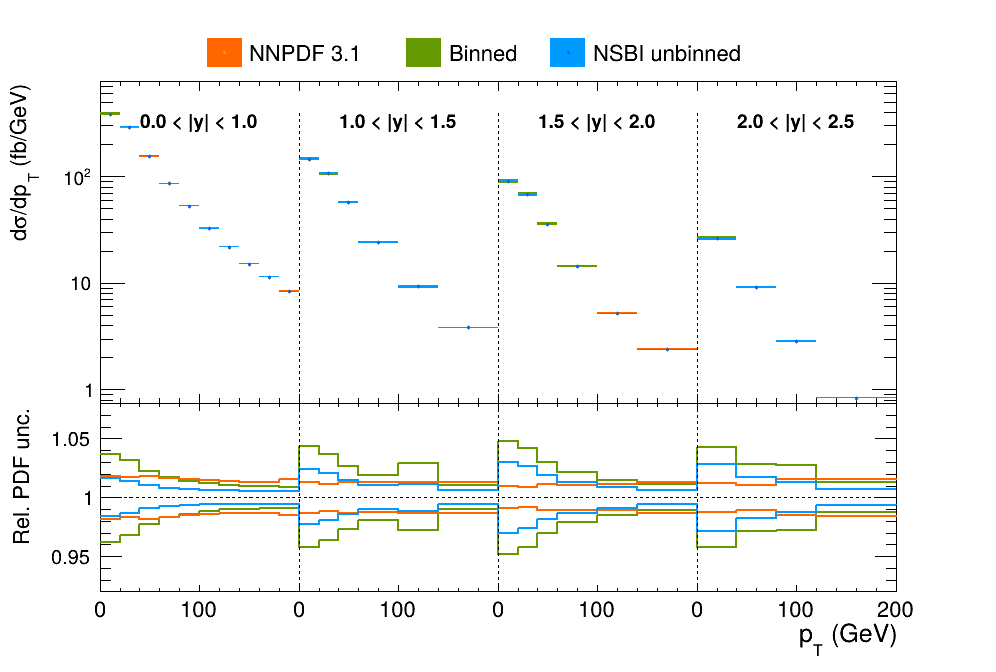

In [30]:
c = ROOT.TCanvas("c", "", 1000, 700)

# Top pad for histograms
pad1 = ROOT.TPad("pad1", "", 0, 0.4, 1, 1)
pad1.SetBottomMargin(0.0)  # hide x-axis
pad1.SetTopMargin(0.2)  # hide x-axis
pad1.SetTicks(1,1)
pad1.Draw()

# Bottom pad for error/rate
pad2 = ROOT.TPad("pad2", "", 0, 0.0, 1, 0.4)
pad2.SetTopMargin(0.0)
pad2.SetBottomMargin(0.3)  # leave space for labels
pad2.SetTicks(1,1)
pad2.Draw()

pad1.cd()

for i in range(len(gps)):
    g = gps[i]
    g.GetXaxis().SetLabelOffset(999)
    g.SetMaximum(gmax*2)
    g.SetFillColor(fillcolors[i])
    g.SetFillStyle(1001)
    g.SetLineColor(ROOT.kBlack)
    g.SetMarkerStyle(20)
    g.SetMarkerSize(0.3)
    g.SetMarkerColor(pointcolors[i])
    modifylabels(g.GetXaxis())
    g.GetYaxis().SetLabelSize(0.05)
    g.GetXaxis().SetTitle("p_{T} (GeV)")
    g.GetYaxis().SetTitle("d#sigma/dp_{T} (fb/GeV)")
    g.GetYaxis().SetTitleSize(0.06)
    g.GetYaxis().SetTitleOffset(0.8)
    g.GetXaxis().SetRangeUser(0, xmax)
    g.SetLineWidth(0)
    if i == 0:
        g.Draw("AE2")
    else:
        g.Draw("E2 SAME")
    g.Draw("PSAME")
    pad1.SetLogy()

lines = []
for i in line_pos:
    line = ROOT.TLine(i, 0, i, gmax*1.0)
    line.SetLineStyle(2)
    line.Draw()
    lines.append(line)

if len(line_pos) > 1:
    text_center = [line_pos[0]/2]
    for i in range(1, len(line_pos)):
        text_center.append((line_pos[i]+line_pos[i-1])/2)
#text_center.append((nbins-line_pos[-1])/2+line_pos[-1])

latex = ROOT.TLatex()
latex.SetTextAlign(22)
latex.SetTextSize(0.05)

for i in range(n_slices):
    x_center = text_center[i] 
    label = f"{y_bins[i]:.1f} < |y| < {y_bins[i+1]:.1f}"
    latex.DrawLatex(x_center, gmax*0.8, label)

pad2.cd()

yerrmin = 0.92
yerrmax = 1.08
for i in range(len(gerrs)):
    gerr = gerrs[i]
    # Configure axis
    gerr.SetMinimum(yerrmin)
    gerr.SetMaximum(yerrmax)
    gerr.SetTitle("")  # no main title

    modifylabels(gerr.GetXaxis())
    gerr.GetXaxis().SetTitle("p_{T} (GeV)")
    gerr.GetXaxis().SetRangeUser(0, xmax)
    gerr.GetXaxis().SetTitleSize(0.1)
    gerr.GetXaxis().SetTitleOffset(1.1)
    gerr.GetXaxis().SetLabelOffset(0.03)
    gerr.GetXaxis().SetLabelSize(0.08)

    gerr.GetYaxis().SetTitle("Rel. PDF unc.")
    gerr.GetYaxis().SetTitleSize(0.09)
    gerr.GetYaxis().SetLabelSize(0.08)
    gerr.GetYaxis().SetLabelOffset(0.01)
    gerr.GetYaxis().SetNdivisions(505)

    # Draw band
    gerr.SetFillStyle(1001)
    gerr.GetYaxis().SetTitleOffset(0.55)
    gerr.SetFillColor(fillcolors[i])
    gerr.SetLineColor(fillcolors[i])
    gerr.SetFillColorAlpha(fillcolors[i], 0.6)
    gerr.SetLineWidth(0)
    gerr.SetMarkerSize(0)
    if i == 0:
        gerr.Draw("A P")
    else:
        gerr.Draw("P SAME")
    gerrups[i].SetLineColor(fillcolors[i])
    gerrdns[i].SetLineColor(fillcolors[i])
    gerrups[i].SetLineWidth(2)
    gerrdns[i].SetLineWidth(2)
    gerrups[i].SetMarkerSize(0)
    gerrdns[i].SetMarkerSize(0)
    gerrups[i].Draw("LEZ SAME")
    gerrdns[i].Draw("LEZ SAME")
    gerrups[i].Draw("LEZ SAME")
    gerrdns[i].Draw("LEZ SAME")
# Vertical separator lines in bottom pad
for i in line_pos:
    line = ROOT.TLine(i, yerrmin, i, yerrmax)
    line.SetLineStyle(2)
    line.Draw()
    lines.append(line)
line = ROOT.TLine(0, 1, xmax, 1)
line.SetLineStyle(2)
line.Draw()
lines.append(line)

pad1.cd()
l = ROOT.TLegend(0.2, 0.82, 0.8, 0.92)
l.SetNColumns(3)
for i in legend_order:
    g = gps[i]
    l.AddEntry(g, legends[i], "pf")
#g_copy = g.Clone("g_copy")
#g_copy.SetLineColor(ROOT.kGray)
#l.AddEntry(g_copy, "NSBI unbinned", "f")
#l.AddEntry(gerr, "PDF variation (relative uncertainty)", "f")
l.SetBorderSize(0)
l.Draw()


c.Draw()


In [31]:
c.SaveAs("./ggHPDF.pdf")

Appending file ./ggHPDF.pdf
Appending file /tmp/tmpvpz2w4vd.png


Info in <TCanvas::Print>: pdf file ./ggHPDF.pdf has been created


In [32]:
c.SaveAs("./ggHPDF.root")

Appending file ./ggHPDF.root


Info in <TCanvas::SaveAs>: ROOT file ./ggHPDF.root has been created
